# Benchmarking – Connect-4 Dataset

So sánh hiệu năng thuật toán **FP-Growth (Julia) From Scratch** và **SPMF (Java) Built-in** trên dataset Connect-4.

| Thông tin | Giá trị |
|---|---|
| Số giao dịch | 67,557 |
| Items/transaction | 42 (126 items mã hoá) |
| Nguồn | UCI Machine Learning Repository |

## 🧩 Giới thiệu về Dataset: Connect-4 opening database

Dataset này chứa tất cả các vị trí quân cờ hợp lệ trong trò chơi Connect-4 sau 8 lượt đi mà chưa có bên nào thắng. 
- **Số lượng instance:** 67,557 giao dịch.
- **Số thuộc tính:** 42 thuộc tính (tương ứng với 42 ô trên bàn cờ 6x7).
- **Giá trị:** Mỗi ô có 3 trạng thái: `x` (người chơi 1), `o` (người chơi 2), `b` (trống).
- **Mục tiêu:** Khai thác các tập phổ biến (frequent patterns) của các nước đi/vị trí bàn cờ thường xuyên xuất hiện cùng nhau.

In [ ]:
# 🛠️ Bước 2: Biến đổi dữ liệu từ .zip -> .dat (SPMF format)
# Chúng ta sẽ thực hiện giải nén và chuyển đổi categorical -> integer encoding

println("🚀 Bắt đầu quá trình chuẩn bị dữ liệu...")

# 1. Định nghĩa đường dẫn
zip_path = "../data/benchmark/connect+4.zip"
extract_dir = "../data/benchmark/connect+4/"
raw_z_path = joinpath(extract_dir, "connect-4.data.Z")
spmf_out_path = "../data/benchmark/connect-4.dat"

# 2. Giải nén ZIP
if !isdir(extract_dir)
    mkpath(extract_dir)
end

println("📦 Đang giải nén file ZIP...")
run(`powershell -Command "Expand-Archive -Path $zip_path -DestinationPath $extract_dir -Force"`)

# 3. Giải nén .Z và Chuyển đổi (Sử dụng Python bridge)
println("⚙️ Đang giải nén .Z và chuyển đổi sang định dạng SPMF...")

py_script = """
import sys, os
from pathlib import Path
try:
    from unlzw3 import unlzw
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'unlzw3'])
    from unlzw3 import unlzw

raw_z = r'" + raw_z_path + "'
out_dat = r'" + spmf_out_path + "'

if not os.path.exists(raw_z):
    raise FileNotFoundError(f'Không tìm thấy file: {raw_z}')

raw_bytes = Path(raw_z).read_bytes()
decompressed = unlzw(raw_bytes).decode('utf-8')

VALUE_MAP = {'x': 0, 'o': 1, 'b': 2}
lines = []
for line in decompressed.strip().split('\n'):
    parts = line.split(',')
    if len(parts) >= 42:
        items = [str(i * 3 + VALUE_MAP[val.strip()]) for i, val in enumerate(parts[:42])]
        lines.append(' '.join(items))

Path(out_dat).write_text('\n'.join(lines))
"""

run(`python -c $py_script`)

println("✅ Hoàn tất! Dữ liệu đã sẵn sàng tại: $spmf_out_path")

In [11]:
# ── Imports & Setup ──────────────────────────────────────────────────────────
using CSV, DataFrames, Plots, ProgressMeter, Statistics
using Plots.PlotMeasures

include("../src/FPGrowth.jl")
using .FPGrowth

include("../src/logger.jl")
logger = Logger()

include("../src/utils.jl")
include("../src/eval.jl")
using .Utils
success(logger, "Môi trường sẵn sàng!")


[success] Môi trường sẵn sàng!


In [ ]:
# ── Cấu hình ─────────────────────────────────────────────────────────────────
config = Dict{String, Any}(
    "dataset"         => "../data/benchmark/connect-4.dat",
    "java_path"       => "java",
    "spmf_jar"        => "../spmf.jar",
    "output_spmf"     => "../results/connect4_spmf_out.txt",
    "csv_minsup"      => "../results/connect4_performance.csv",
    "csv_scalability" => "../results/connect4_scalability.csv",
    "min_sups"                   => [0.75, 0.80, 0.85, 0.9],
    "n_benchmark_runs"           => 5,
    "data_ratios"                => [0.25, 0.50, 0.75, 1.0],
    "fixed_minsup_for_scalability" => 0.90,
)
success(logger, "Config loaded – dataset: connect-4.dat  (67,557 transactions)")


[success] Config loaded – dataset: connect-4.dat  (67,557 transactions)


In [ ]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
function eval_performance_c4(config)
    process(logger, "Đang Warmup JIT Compiler...")
    FPGrowth.fpgrowth([[1,2], [1,3], [1,2,3]], 1)
    phase(logger, "PERFORMANCE – Connect-4")

    transactions = FPGrowth.read_spmf(config["dataset"])
    total_txs = length(transactions)
    info(logger, "Tổng số giao dịch: ", total_txs)

    N_RUNS = get(config, "n_benchmark_runs", 5)
    results_df = DataFrame(
        MinSup=Float64[], JuliaTime=Float64[], JuliaMemMB=Float64[],
        SPMFTime=Float64[], SPMFMemMB=Float64[]
    )

    @showprogress "Đang đo hiệu năng... " for min_sup_ratio in config["min_sups"]
        process(logger, "min_sup = ", min_sup_ratio * 100, "%  (", N_RUNS, " runs)")
        min_sup_abs = ceil(Int, min_sup_ratio * total_txs)

        # Julia – median of N_RUNS
        julia_times = Float64[]
        julia_mems  = Float64[]
        for _ in 1:N_RUNS
            GC.gc()
            mem_bytes = @allocated begin
                t0 = time_ns()
                FPGrowth.fpgrowth(transactions, min_sup_abs)
                t1 = time_ns()
            end
            push!(julia_times, (t1 - t0) / 1e9)
            push!(julia_mems,  mem_bytes / (1024^2))
        end
        julia_time   = median(julia_times)
        julia_mem_mb = median(julia_mems)

        # SPMF
        spmf_time, spmf_mem_mb = execute_spmf(config, config["dataset"], config["output_spmf"], min_sup_ratio)

        metric(logger, "Julia → Time: ", round(julia_time, digits=3), "s | RAM: ", round(julia_mem_mb, digits=2), " MB")
        metric(logger, "SPMF  → Time: ", round(spmf_time, digits=3), "s | RAM: ", round(spmf_mem_mb, digits=2), " MB")
        push!(results_df, (min_sup_ratio, julia_time, julia_mem_mb, spmf_time, spmf_mem_mb))
    end

    CSV.write(config["csv_minsup"], results_df)
    success(logger, "Saved → ", config["csv_minsup"])
    return results_df
end

df_perf = eval_performance_c4(config)


[process] Đang Warmup JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE – Connect-4
__________________________________________________



__________________________________________________
[phase]  VIS PERFORMANCE – Connect-4
__________________________________________________


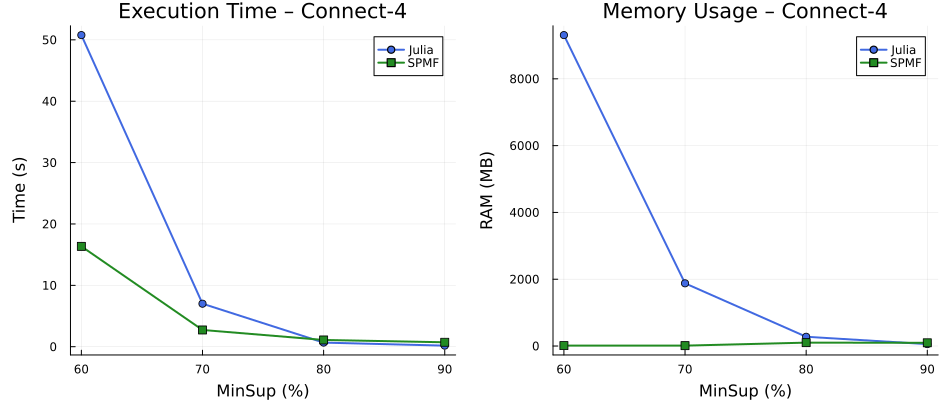

In [10]:
# ── Visualise Performance ────────────────────────────────────────────────────
function vis_performance_c4(df::DataFrame)
    phase(logger, "VIS PERFORMANCE – Connect-4")
    df_s = sort(df, :MinSup, rev=true)
    x    = df_s.MinSup .* 100

    p_time = plot(x, df_s.JuliaTime, label="Julia", marker=:circle, linewidth=2, color=:royalblue,
                  title="Execution Time – Connect-4", xlabel="MinSup (%)", ylabel="Time (s)", legend=:topright)
    plot!(p_time, x, df_s.SPMFTime,  label="SPMF",  marker=:square, linewidth=2, color=:forestgreen)

    p_mem  = plot(x, df_s.JuliaMemMB, label="Julia", marker=:circle, linewidth=2, color=:royalblue,
                  title="Memory Usage – Connect-4", xlabel="MinSup (%)", ylabel="RAM (MB)", legend=:topright)
    plot!(p_mem, x, df_s.SPMFMemMB,  label="SPMF",  marker=:square, linewidth=2, color=:forestgreen)

    display(plot(p_time, p_mem, layout=(1,2), size=(950, 420), bottom_margin=8mm, left_margin=6mm))
end

vis_performance_c4(df_perf)


In [ ]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
function eval_scalability_c4(config)
    process(logger, "Đang Warmup JIT Compiler...")
    FPGrowth.fpgrowth([[1,2], [1,3], [1,2,3]], 1)
    phase(logger, "SCALABILITY – Connect-4")

    transactions  = FPGrowth.read_spmf(config["dataset"])
    total_txs     = length(transactions)
    fixed_minsup  = config["fixed_minsup_for_scalability"]
    info(logger, "Fixed MinSup = ", fixed_minsup * 100, "%")

    results_df = DataFrame(DataRatio=Float64[], NumTransactions=Int[], JuliaTime=Float64[], SPMFTime=Float64[])

    @showprogress "Đang đo độ mở rộng... " for ratio in config["data_ratios"]
        num_tx = ceil(Int, total_txs * ratio)
        process(logger, "Data Ratio = ", ratio * 100, "% (", num_tx, " giao dịch)")

        sliced = transactions[1:num_tx]
        tmp    = "../results/tmp_connect4_$(ratio).dat"
        open(tmp, "w") do f
            for tx in sliced; println(f, join(tx, " ")); end
        end

        min_sup_abs = ceil(Int, fixed_minsup * num_tx)

        # Julia
        GC.gc()
        t0 = time_ns()
        FPGrowth.fpgrowth(sliced, min_sup_abs)
        t1 = time_ns()
        julia_time = (t1 - t0) / 1e9

        # SPMF
        spmf_time, _ = execute_spmf(config, tmp, config["output_spmf"], fixed_minsup)

        metric(logger, "Julia: ", round(julia_time, digits=3), "s | SPMF: ", round(spmf_time, digits=3), "s")
        push!(results_df, (ratio, num_tx, julia_time, spmf_time))
        rm(tmp, force=true)
    end

    CSV.write(config["csv_scalability"], results_df)
    success(logger, "Saved → ", config["csv_scalability"])
    return results_df
end

df_scale = eval_scalability_c4(config)


In [ ]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
function vis_scalability_c4(df::DataFrame)
    phase(logger, "VIS SCALABILITY – Connect-4")
    x = df.DataRatio .* 100

    p = plot(x, df.JuliaTime, label="Julia", marker=:circle, linewidth=2, color=:royalblue,
             title="Scalability – Connect-4", xlabel="Data ratio (%)", ylabel="Execution time (s)", legend=:topleft)
    plot!(p, x, df.SPMFTime, label="SPMF", marker=:square, linewidth=2, color=:forestgreen)

    display(plot(p, size=(700, 420), bottom_margin=8mm, left_margin=6mm))
end

vis_scalability_c4(df_scale)


## 📋 Kết quả tổng hợp

Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame.

In [ ]:
# ── Kết quả dạng bảng ───────────────────────────────────────────────────────
println("=== PERFORMANCE ===")
display(df_perf)
println()
println("=== SCALABILITY ===")
display(df_scale)
